In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Make charts look clean
plt.style.use("ggplot")

In [3]:
url = "https://remotive.com/api/remote-jobs"

try:
    response = requests.get(url, timeout=10)
    response.raise_for_status()
    data = response.json()
    print("Data fetched successfully!")
except requests.exceptions.RequestException as e:
    print("Error fetching data:", e)

Data fetched successfully!


In [4]:
jobs = data["jobs"]
df = pd.DataFrame(jobs)
print("Total Jobs Fetched:", len(df))
df.head()

Total Jobs Fetched: 19


,id,url,title,company_name,company_logo,category,tags,job_type,publication_date,candidate_required_location,salary,description,company_logo_url
0,1749306,https://remotive.com/remote-jobs/writing/copyw...,Copywriter,Coalition Technologies,https://remotive.com/job/1749306/logo,Writing,"[accounting, excel, research, data analysis, b...",freelance,2026-03-02T20:01:28,Worldwide,$20k -$35k,"<p class=""h3""> </p>\n<div class=""h3"">WHO WE'RE...",https://remotive.com/job/1749306/logo
1,2082736,https://remotive.com/remote-jobs/marketing/sen...,Senior Amazon Brand Manager,GNO Partners,https://remotive.com/job/2082736/logo,Marketing,"[amazon, backend, project management, PPC]",full_time,2026-02-26T07:45:46,Worldwide,$220k-$300k OTE,"<p style=""margin-bottom: 20px; padding: 0px; b...",https://remotive.com/job/2082736/logo
2,2088639,https://remotive.com/remote-jobs/sales-busines...,🇩🇪 Account Director (m/w/d),VONQ NL,https://remotive.com/job/2088639/logo,Sales / Business,"[account management, R, REST]",full_time,2026-02-25T15:29:13,Germany,,<p><strong>🇩🇪 This job ad is written in German...,NaN
3,2088637,https://remotive.com/remote-jobs/devops/red-te...,Red Team Specialist (Offensive Security),Lumitekno Kreasi Global,https://remotive.com/job/2088637/logo,DevOps / Sysadmin,"[security, SOLID, testing, shell, CMS]",full_time,2026-02-23T10:52:54,Worldwide,$65K - $80K,"<div class=""h3""><strong>Red Team Specialist (O...",https://remotive.com/job/2088637/logo
4,2088635,https://remotive.com/remote-jobs/project-manag...,Order Management and Operations Manager,Exaware,https://remotive.com/job/2088635/logo,Project Management,"[excel, documentation, CRM, hardware, business...",full_time,2026-02-19T13:06:05,USA,$50K-$60K,<p>We are now seeking a talented and detail-or...,NaN


In [5]:
df.columns

Index(['id', 'url', 'title', 'company_name', 'company_logo', 'category',
       'tags', 'job_type', 'publication_date', 'candidate_required_location',
       'salary', 'description', 'company_logo_url'],
      dtype='object')

In [6]:
df = df[[
    "title",
    "company_name",
    "category",
    "candidate_required_location",
    "salary",
    "publication_date",
    "tags"
]]
df.head()

,title,company_name,category,candidate_required_location,salary,publication_date,tags
0,Copywriter,Coalition Technologies,Writing,Worldwide,$20k -$35k,2026-03-02T20:01:28,"[accounting, excel, research, data analysis, b..."
1,Senior Amazon Brand Manager,GNO Partners,Marketing,Worldwide,$220k-$300k OTE,2026-02-26T07:45:46,"[amazon, backend, project management, PPC]"
2,🇩🇪 Account Director (m/w/d),VONQ NL,Sales / Business,Germany,,2026-02-25T15:29:13,"[account management, R, REST]"
3,Red Team Specialist (Offensive Security),Lumitekno Kreasi Global,DevOps / Sysadmin,Worldwide,$65K - $80K,2026-02-23T10:52:54,"[security, SOLID, testing, shell, CMS]"
4,Order Management and Operations Manager,Exaware,Project Management,USA,$50K-$60K,2026-02-19T13:06:05,"[excel, documentation, CRM, hardware, business..."


In [7]:
df.columns = [
    "Job_Title",
    "Company",
    "Category",
    "Location",
    "Salary",
    "Posted_Date",
    "Skills"
]
df.head()

,Job_Title,Company,Category,Location,Salary,Posted_Date,Skills
0,Copywriter,Coalition Technologies,Writing,Worldwide,$20k -$35k,2026-03-02T20:01:28,"[accounting, excel, research, data analysis, b..."
1,Senior Amazon Brand Manager,GNO Partners,Marketing,Worldwide,$220k-$300k OTE,2026-02-26T07:45:46,"[amazon, backend, project management, PPC]"
2,🇩🇪 Account Director (m/w/d),VONQ NL,Sales / Business,Germany,,2026-02-25T15:29:13,"[account management, R, REST]"
3,Red Team Specialist (Offensive Security),Lumitekno Kreasi Global,DevOps / Sysadmin,Worldwide,$65K - $80K,2026-02-23T10:52:54,"[security, SOLID, testing, shell, CMS]"
4,Order Management and Operations Manager,Exaware,Project Management,USA,$50K-$60K,2026-02-19T13:06:05,"[excel, documentation, CRM, hardware, business..."


In [8]:
df.isnull().sum()

,0
Job_Title,0
Company,0
Category,0
Location,0
Salary,0
Posted_Date,0
Skills,0


In [9]:
df["Salary"] = df["Salary"].fillna("Not Disclosed")

In [10]:
df["Skills"] = df["Skills"].apply(lambda x: ", ".join(x) if isinstance(x, list) else x)
df.head()

,Job_Title,Company,Category,Location,Salary,Posted_Date,Skills
0,Copywriter,Coalition Technologies,Writing,Worldwide,$20k -$35k,2026-03-02T20:01:28,"accounting, excel, research, data analysis, bo..."
1,Senior Amazon Brand Manager,GNO Partners,Marketing,Worldwide,$220k-$300k OTE,2026-02-26T07:45:46,"amazon, backend, project management, PPC"
2,🇩🇪 Account Director (m/w/d),VONQ NL,Sales / Business,Germany,,2026-02-25T15:29:13,"account management, R, REST"
3,Red Team Specialist (Offensive Security),Lumitekno Kreasi Global,DevOps / Sysadmin,Worldwide,$65K - $80K,2026-02-23T10:52:54,"security, SOLID, testing, shell, CMS"
4,Order Management and Operations Manager,Exaware,Project Management,USA,$50K-$60K,2026-02-19T13:06:05,"excel, documentation, CRM, hardware, business ..."


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Job_Title    19 non-null     object
 1   Company      19 non-null     object
 2   Category     19 non-null     object
 3   Location     19 non-null     object
 4   Salary       19 non-null     object
 5   Posted_Date  19 non-null     object
 6   Skills       19 non-null     object
dtypes: object(7)
memory usage: 1.2+ KB


/tmp/ipykernel_186/1143766704.py:8: UserWarning: Glyph 127465 (\N{REGIONAL INDICATOR SYMBOL LETTER D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_186/1143766704.py:8: UserWarning: Glyph 127466 (\N{REGIONAL INDICATOR SYMBOL LETTER E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_186/1143766704.py:9: UserWarning: Glyph 127465 (\N{REGIONAL INDICATOR SYMBOL LETTER D}) missing from font(s) DejaVu Sans.
  plt.savefig("top_job_titles.png")
/tmp/ipykernel_186/1143766704.py:9: UserWarning: Glyph 127466 (\N{REGIONAL INDICATOR SYMBOL LETTER E}) missing from font(s) DejaVu Sans.
  plt.savefig("top_job_titles.png")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127465 (\N{REGIONAL INDICATOR SYMBOL LETTER D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127466 (\N{REGIONAL INDICATOR SY

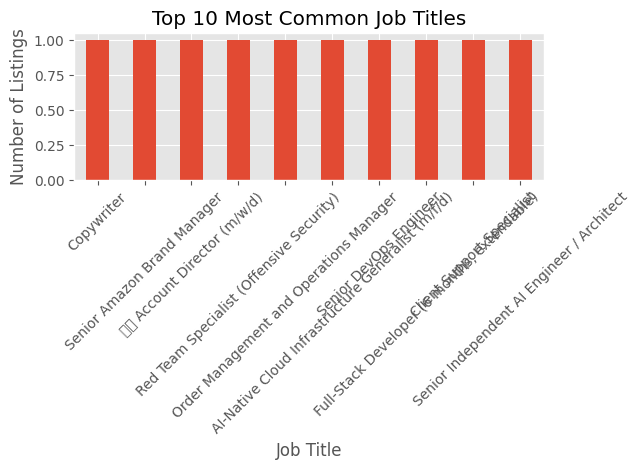

,count
Job_Title,
Copywriter,1
Senior Amazon Brand Manager,1
🇩🇪 Account Director (m/w/d),1
Red Team Specialist (Offensive Security),1
Order Management and Operations Manager,1
AI-Native Cloud Infrastructure Generalist (m/f/d),1
Senior DevOps Engineer,1
"Full-Stack Developer (6 months, extendable)",1
Client Support Specialist,1


In [17]:
top_titles = df["Job_Title"].value_counts().head(10)
plt.figure()
top_titles.plot(kind="bar")
plt.title("Top 10 Most Common Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("top_job_titles.png")
plt.show()
top_titles

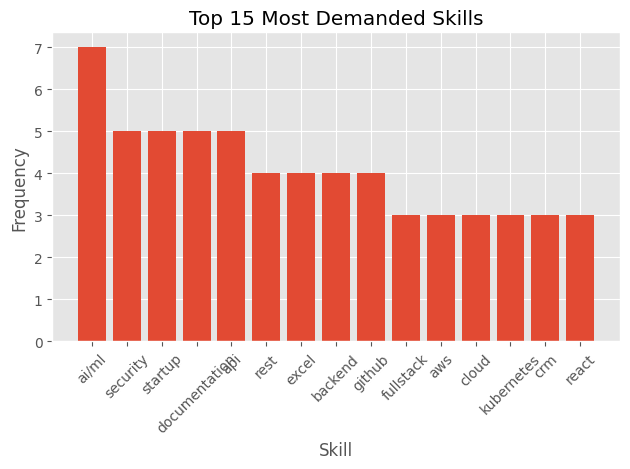

,Skill,Count
32,ai/ml,7
17,security,5
34,startup,5
22,documentation,5
45,api,5
16,rest,4
1,excel,4
11,backend,4
54,github,4
30,fullstack,3


In [18]:
from collections import Counter

all_skills = []

for skills in df["Skills"].dropna():
    skill_list = [skill.strip().lower() for skill in skills.split(",")]
    all_skills.extend(skill_list)

skill_counts = Counter(all_skills)

top_skills = pd.DataFrame(skill_counts.items(), columns=["Skill", "Count"])
top_skills = top_skills.sort_values(by="Count", ascending=False).head(15)

plt.figure()
plt.bar(top_skills["Skill"], top_skills["Count"])
plt.title("Top 15 Most Demanded Skills")
plt.xlabel("Skill")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("top_15_most_demanded_skills.png")
plt.show()

top_skills

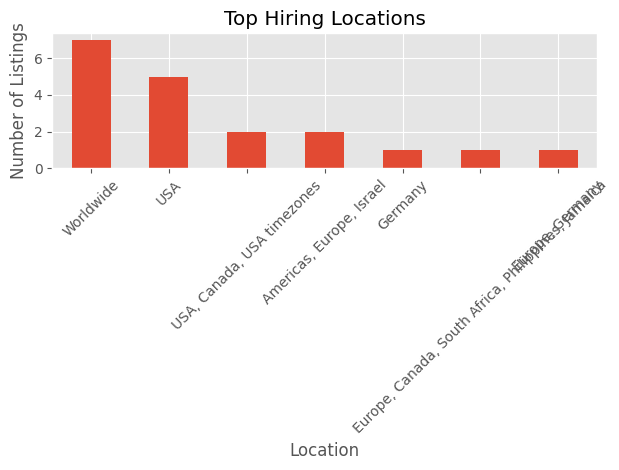

,count
Location,
Worldwide,7
USA,5
"USA, Canada, USA timezones",2
"Americas, Europe, Israel",2
Germany,1
"Europe, Canada, South Africa, Philippines, Jamaica",1
"Europe, Germany",1


In [19]:
top_locations = df["Location"].value_counts().head(10)

plt.figure()
top_locations.plot(kind="bar")
plt.title("Top Hiring Locations")
plt.xlabel("Location")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("top_hiring_location.png")
plt.show()

top_locations

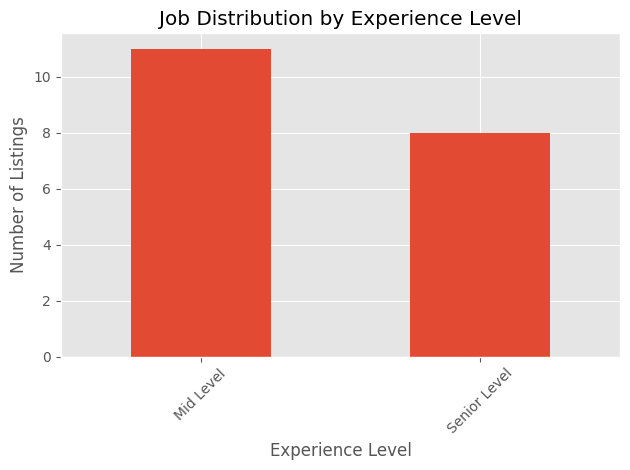

,count
Experience_Level,
Mid Level,11
Senior Level,8


In [20]:
def classify_level(title):
    title = title.lower()
    if "senior" in title or "lead" in title or "manager" in title:
        return "Senior Level"
    elif "junior" in title or "associate" in title or "entry" in title:
        return "Entry Level"
    else:
        return "Mid Level"

df["Experience_Level"] = df["Job_Title"].apply(classify_level)

level_counts = df["Experience_Level"].value_counts()

plt.figure()
level_counts.plot(kind="bar")
plt.title("Job Distribution by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("job_distribution_experience_lvl.png")
plt.show()

level_counts

In [16]:
df.to_csv("cleaned_job_data.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
